In [7]:
# Installing the core Gradient Boosting Machine engine
install.packages("gbm")

# Installing the Classification and REgression Training framework
install.packages("caret")

# Installing the tools for Receiver Operating Characteristic analysis
install.packages("pROC")

# Installing the necessary library for Excel files
install.packages("readxl")

install.packages("tidyverse")

install.packages("ggcorrplot")

The following package(s) will be installed:
- gbm [2.2.3]
These packages will be installed into "C:/Users/bonhe/Repositories/gbm-learning-strategy/renv/library/windows/R-4.5/x86_64-w64-mingw32".

# Installing packages --------------------------------------------------------
✔ gbm 2.2.3                                [linked from cache]
The following package(s) will be installed:
- caret [7.0-1]
These packages will be installed into "C:/Users/bonhe/Repositories/gbm-learning-strategy/renv/library/windows/R-4.5/x86_64-w64-mingw32".

# Installing packages --------------------------------------------------------
✔ caret 7.0-1                              [linked from cache]
The following package(s) will be installed:
- pROC [1.19.0.1]
These packages will be installed into "C:/Users/bonhe/Repositories/gbm-learning-strategy/renv/library/windows/R-4.5/x86_64-w64-mingw32".

# Installing packages --------------------------------------------------------
✔ pROC 1.19.0.1                            

In [3]:
library(gbm)
library(caret)
library(pROC)
library(readxl)

Loaded gbm 2.2.3

This version of gbm is no longer under development. Consider transitioning to gbm3, https://github.com/gbm-developers/gbm3

Loading required package: ggplot2

Loading required package: lattice

Type 'citation("pROC")' for a citation.


Attaching package: 'pROC'


The following objects are masked from 'package:stats':

    cov, smooth, var




In [4]:
student_data_final <- read_excel("data_src_2.xlsx")

completion_rate <- sum(!is.na(student_data_final)) / (nrow(student_data_final) * ncol(student_data_final)) * 100
cat("Taux de complétude :", round(completion_rate, 2), "%")

# 2. Vérifier s'il reste des valeurs manquantes par colonne (doit être 0 partout)
colSums(is.na(student_data_final))

# 3. Résumé pour le Tableau 4.1
summary_audit <- data.frame(
  Variable_Count = ncol(student_data_final),
  Total_Observations = nrow(student_data_final),
  Missing_Values_After_Cleaning = sum(is.na(student_data_final))
)
print(summary_audit)

Taux de complétude : 100 %

sn                  student_id 
                          0                           0 
                  school_id     power_cut_hour_per_week 
                          0                           0 
            study_during_pc      study_quiet_place_1_10 
                          0                           0 
study_interruption_per_hour        sleep_hour_per_night 
                          0                           0 
         sleep_quality_1_10                 stress_1_10 
                          0                           0 
          technostress_1_10         cognitive_load_1_10 
                          0                           0 
            resilience_1_10 digital_education_hour_week 
                          0                           0 
      social_media_hour_day                      device 
                          0                           0 
             ai_use_req_1_5            commute_hour_day 
                          0                           0 
    hour_searching_per_week           active_recall_1_5 
                          0                           0 
         self_test_per_week           Independent_study 
                          0                           0 
    past_test_hour_per_week                       tutor 
                          0                           0 
        tutor_hour_per_week           spaced_repetition 
                          0                           0 
               absence_days    instruction_clarity_1_10 
                          0                           0 
                     gender                         age 
                          0                           0 
                   language                      stream 
                          0                           0 
                 class_size          chore_hour_per_day 
                          0                           0 
                 mock_score                      Result 
                          0                           0

  Variable_Count Total_Observations Missing_Values_After_Cleaning
1             36                300                             0


## Heatmap


[1] "--- Top des interactions détectées dans le dataset ---"


,Var1,Var2,Freq
,<fct>,<fct>,<dbl>
1,deviceNone,streamG,1.0000000
2,streamG,deviceNone,1.0000000
3,instruction_clarity_1_10,resilience_1_10,0.9989062
4,resilience_1_10,instruction_clarity_1_10,0.9989062
5,chore_hour_per_day,sleep_hour_per_night,-0.9914895
6,sleep_hour_per_night,chore_hour_per_day,-0.9914895
7,mock_score,sleep_quality_1_10,0.9913145
8,sleep_quality_1_10,mock_score,0.9913145
9,resilience_1_10,sleep_quality_1_10,0.9912177


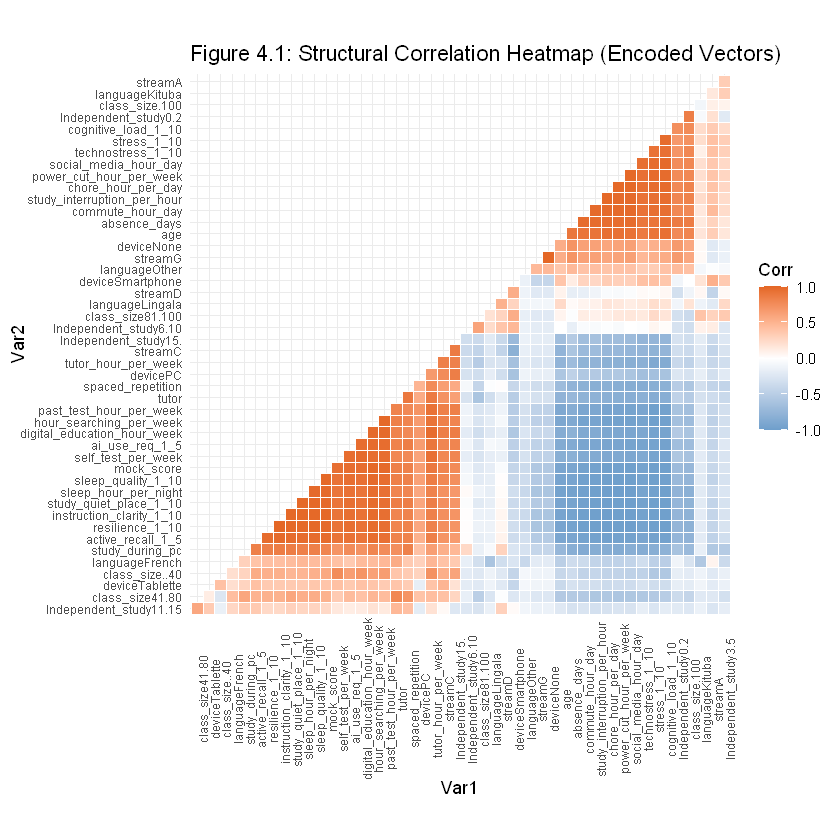

In [9]:
# 1. Chargement des bibliothèques
library(readxl)
library(caret)
library(ggcorrplot)
library(tidyverse)

# 2. Importation et Nettoyage initial
student_data <- read_excel("data_src_2.xlsx")

# 3. Encodage des variables catégorielles (Transformation en vecteurs numériques)
# On suit exactement votre logique de dummyVars
categorical_vars <- c("language", "stream", "device", "Independent_study", "class_size")
encoder_model <- dummyVars(~ language + stream + device + Independent_study + class_size, data = student_data)
encoded_features <- data.frame(predict(encoder_model, newdata = student_data))

# 4. Construction de la matrice finale (student_data_final)
# On retire les colonnes texte et les ID pour ne garder que le numérique
columns_to_remove <- c(categorical_vars, "student_id", "school_id", "sn", "gender", "Result")
# Note : on garde Mock_score et on s'assure que tout est numérique
student_data_final <- cbind(student_data[, !(names(student_data) %in% columns_to_remove)], encoded_features)

# Conversion forcée en numérique pour éviter les erreurs de corrélation
student_data_numeric <- student_data_final %>% 
  mutate(across(everything(), as.numeric)) %>%
  na.omit() # On nettoie les éventuels NA créés par la transformation

# 5. Calcul de la matrice de corrélation
corr_matrix <- cor(student_data_numeric, use = "pairwise.complete.obs")

# 6. Génération de la Heatmap (Figure 4.1)
heatmap_plot <- ggcorrplot(corr_matrix, 
                           hc.order = TRUE, 
                           type = "lower", 
                           outline.col = "white",
                           colors = c("#6D9ECB", "white", "#E46726"),
                           title = "Figure 4.1: Structural Correlation Heatmap (Encoded Vectors)",
                           show.diag = FALSE) +
                theme_minimal() +
                theme(axis.text.x = element_text(angle = 90, size = 7),
                      axis.text.y = element_text(size = 7))

print(heatmap_plot)

# 7. Output pour la rédaction : Identification des relations clés
high_corr <- as.data.frame(as.table(corr_matrix)) %>%
  filter(abs(Freq) > 0.4 & Var1 != Var2) %>%
  arrange(desc(abs(Freq)))

print("--- Top des interactions détectées dans le dataset ---")
head(high_corr, 15)